# 🔄 The Reflection Pattern — AI That Improves Its Own Work

**Video:** *Agentic Design Patterns Part 1: Reflection* | **Channel:** Prashant Nair (@prashantnairofficial)

---

### The Pattern:
```
Generate → Critique → Improve → Critique → Improve → ... → Approved ✅
```

### What We're Building:
An **AI Code Reviewer** that writes Python code, critiques it against a quality rubric, and iteratively improves it until it meets production standards.

### The Analogy:
Reflection is giving AI the ability to do a **second draft**. Just like a developer writes, reviews, and refactors — the AI generates, critiques, and improves.

---

**Tech Stack:** LangGraph, LangChain, OpenAI (gpt-4o-mini)  
**Author:** Prashant Nair | AI & GenAI Practitioner | Principal Trainer

## 📦 Step 1: Install Dependencies

In [1]:
!pip install --quiet langchain==0.3.25 langchain-core==0.3.62 langchain-openai==0.3.18 langgraph==0.3.34 grandalf


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.4/438.4 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.4/63.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.2/148.2 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.3/50.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.0/363.0 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 83.2 MB/s eta 0:00:00


## 🔐 Step 2: Configure OpenAI

In [2]:
from google.colab import userdata
import os

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
print("✅ OpenAI API key configured")

✅ OpenAI API key configured


## 🏗️ Step 3: Define the State

The state tracks everything across iterations:
- The task description
- Current version of the code
- Feedback history from each critique
- Iteration count
- Whether the code is approved

In [3]:
from typing import TypedDict

class ReflectionState(TypedDict):
    task: str                    # What we're asking the AI to code
    code: str                    # Current version of the generated code
    code_history: list[str]      # All versions of the code (V1, V2, V3...)
    feedback_history: list[str]  # Critic's feedback from each iteration
    iteration: int              # Current iteration number
    max_iterations: int         # Safety limit to prevent infinite loops
    approved: bool              # Whether the Critic approved the code

MAX_ITERATIONS = 3  # Stop after 3 iterations max

print("✅ State schema defined")
print(f"   Max iterations: {MAX_ITERATIONS}")

✅ State schema defined
   Max iterations: 3


## 🧠 Step 4: Define the Generator and Critic

**Generator:** Writes (or rewrites) code based on the task and any feedback.

**Critic:** Reviews the code against a specific quality rubric and either approves or provides actionable feedback.

In [4]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.3)

# ── GENERATOR: Writes/improves code ──
def generate_code(state: ReflectionState) -> ReflectionState:
    iteration = state["iteration"] + 1
    print(f"\n{'═' * 60}")
    print(f"✍️  GENERATOR — Iteration {iteration}")
    print(f"{'═' * 60}")

    # Build the prompt based on whether this is first draft or revision
    if iteration == 1:
        user_prompt = f"""Write a Python function for the following task:

TASK: {state['task']}

Write clean, working Python code. Include the function and a brief example of how to use it."""
    else:
        # Include previous feedback for improvement
        feedback = state["feedback_history"][-1]
        user_prompt = f"""Your previous code was reviewed and needs improvement.

TASK: {state['task']}

YOUR PREVIOUS CODE:
{state['code']}

REVIEWER FEEDBACK:
{feedback}

Please rewrite the code addressing ALL the feedback points. Keep what was good, fix what was flagged."""

    response = llm.invoke([
        SystemMessage(content="""You are a senior Python developer. Write clean, production-quality code.
When improving code based on feedback, address every point specifically.
Always include: type hints, docstrings, error handling, and a usage example.
Return ONLY the code — no explanations outside the code block."""),
        HumanMessage(content=user_prompt)
    ])

    code = response.content
    print(f"   Generated {len(code)} characters of code")
    print(f"\n{code[:500]}{'...' if len(code) > 500 else ''}")

    return {
        **state,
        "code": code,
        "code_history": state["code_history"] + [code],
        "iteration": iteration,
    }


# ── CRITIC: Reviews and evaluates code ──
def critique_code(state: ReflectionState) -> ReflectionState:
    print(f"\n{'─' * 60}")
    print(f"🔍 CRITIC — Reviewing Iteration {state['iteration']}")
    print(f"{'─' * 60}")

    response = llm.invoke([
        SystemMessage(content="""You are a strict but fair senior code reviewer. Evaluate the code against this rubric:

1. CORRECTNESS: Does it solve the task correctly?
2. ERROR HANDLING: Does it handle edge cases (empty input, invalid data, missing fields)?
3. TYPE HINTS: Are all function parameters and return types annotated?
4. DOCUMENTATION: Does it have clear docstrings and comments?
5. CODE QUALITY: Clean variable names, DRY principles, proper structure?
6. EDGE CASES: Does it handle boundary conditions?

Your response MUST start with EXACTLY one of:
- "APPROVED" — if the code meets all criteria at a production level
- "NEEDS IMPROVEMENT" — if any criteria are not fully met

After your verdict, provide:
- Score (1-10) for each criterion
- Specific, actionable feedback for any score below 8
- What was done well (acknowledge improvements from previous versions)

Be demanding but fair. Only approve truly production-ready code."""),
        HumanMessage(content=f"""Review this code:

TASK: {state['task']}

CODE:
{state['code']}

This is iteration {state['iteration']} of {state['max_iterations']}.""")
    ])

    feedback = response.content
    approved = feedback.strip().upper().startswith("APPROVED")

    status = "✅ APPROVED" if approved else "🔄 NEEDS IMPROVEMENT"
    print(f"   Verdict: {status}")
    print(f"\n{feedback[:600]}{'...' if len(feedback) > 600 else ''}")

    return {
        **state,
        "feedback_history": state["feedback_history"] + [feedback],
        "approved": approved,
    }

print("✅ Generator and Critic defined")

✅ Generator and Critic defined


## 🔄 Step 5: Build the Reflection Graph

The graph has two nodes (Generator, Critic) connected by a conditional edge:
- If **approved** → END
- If **not approved AND iterations remaining** → back to Generator
- If **max iterations reached** → END (safety exit)

In [5]:
from langgraph.graph import StateGraph, END

def should_continue(state: ReflectionState) -> str:
    """Conditional edge: decide whether to continue the loop."""
    if state["approved"]:
        print(f"\n   ✅ Code APPROVED at iteration {state['iteration']}. Exiting loop.")
        return "end"
    if state["iteration"] >= state["max_iterations"]:
        print(f"\n   ⚠️  Max iterations ({state['max_iterations']}) reached. Exiting loop.")
        return "end"
    print(f"\n   🔄 Sending back to Generator for improvement...")
    return "improve"

# Build the graph
workflow = StateGraph(ReflectionState)

# Add nodes
workflow.add_node("generator", generate_code)
workflow.add_node("critic", critique_code)

# Set entry point
workflow.set_entry_point("generator")

# Generator always goes to Critic
workflow.add_edge("generator", "critic")

# Critic conditionally loops back or ends
workflow.add_conditional_edges(
    "critic",
    should_continue,
    {
        "improve": "generator",  # Loop back
        "end": END,              # Exit
    }
)

# Compile
reflection_agent = workflow.compile()

print("✅ Reflection graph compiled!")
print("   Generator → Critic → [Approved? → END | Needs work? → Generator]")

✅ Reflection graph compiled!
   Generator → Critic → [Approved? → END | Needs work? → Generator]


## 📊 Step 6: Visualize the Reflection Loop

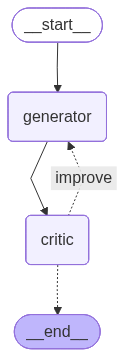

In [6]:
reflection_agent

## 🚀 Step 7: Run It — Watch AI Improve Its Own Code

**The Task:** Write a Python function that processes e-commerce orders and generates a summary report.

Watch how the code evolves across iterations:
- **V1:** Basic implementation (rough first draft)
- **V2:** Improved with feedback (better structure, error handling)
- **V3:** Production-ready (comprehensive, clean, documented)

In [7]:
# ── The Task ──
CODING_TASK = """Write a Python function called `generate_order_report` that:
- Takes a list of dictionaries, where each dictionary represents an e-commerce order
  with keys: 'order_id', 'product', 'quantity', 'price', 'status' (pending/shipped/delivered/cancelled)
- Returns a dictionary summary report containing:
  1. total_revenue (sum of quantity * price for non-cancelled orders)
  2. total_orders (count of all orders)
  3. average_order_value
  4. orders_by_status (count per status)
  5. top_product (product with highest total revenue)
  6. cancellation_rate (percentage of cancelled orders)
"""

print("📋 TASK:")
print(CODING_TASK)
print(f"\n🔄 Starting Reflection Agent (max {MAX_ITERATIONS} iterations)...")
print("\n" + "█" * 60)

# Run the reflection agent
result = reflection_agent.invoke({
    "task": CODING_TASK,
    "code": "",
    "code_history": [],
    "feedback_history": [],
    "iteration": 0,
    "max_iterations": MAX_ITERATIONS,
    "approved": False,
})

print("\n" + "█" * 60)
print(f"\n🏁 REFLECTION COMPLETE")
print(f"   Total iterations: {result['iteration']}")
print(f"   Final status: {'✅ APPROVED' if result['approved'] else '⚠️ Max iterations reached'}")
print(f"   Feedback rounds: {len(result['feedback_history'])}")

📋 TASK:
Write a Python function called `generate_order_report` that:
- Takes a list of dictionaries, where each dictionary represents an e-commerce order
  with keys: 'order_id', 'product', 'quantity', 'price', 'status' (pending/shipped/delivered/cancelled)
- Returns a dictionary summary report containing:
  1. total_revenue (sum of quantity * price for non-cancelled orders)
  2. total_orders (count of all orders)
  3. average_order_value
  4. orders_by_status (count per status)
  5. top_product (product with highest total revenue)
  6. cancellation_rate (percentage of cancelled orders)


🔄 Starting Reflection Agent (max 3 iterations)...

████████████████████████████████████████████████████████████

════════════════════════════════════════════════════════════
✍️  GENERATOR — Iteration 1
════════════════════════════════════════════════════════════
   Generated 2785 characters of code

```python
from typing import List, Dict, Any

def generate_order_report(orders: List[Dict[str, Any]]) -

## 📝 Step 8: View All Versions — The Evolution

This is the visual proof of Reflection. Watch how the code improves from V1 to V3.

In [ ]:
print("\n" + "═" * 60)
print("📄 CODE EVOLUTION — All Versions:")
print("═" * 60)

for i, code_version in enumerate(result["code_history"], 1):
    status = "✅ FINAL (Approved)" if i == len(result["code_history"]) and result["approved"] else "🔄 Draft"
    print(f"\n{'█' * 60}")
    print(f"  VERSION {i}  — {status}")
    print(f"{'█' * 60}")
    print(code_version)
    print()

print(f"\n{'═' * 60}")
print(f"📊 Total versions generated: {len(result['code_history'])}")
print(f"   V1 length: {len(result['code_history'][0])} chars")
if len(result['code_history']) > 1:
    print(f"   Final version length: {len(result['code_history'][-1])} chars")
    growth = len(result['code_history'][-1]) / len(result['code_history'][0])
    print(f"   Code grew by {growth:.1f}x through reflection")


════════════════════════════════════════════════════════════
📄 CODE EVOLUTION — All Versions:
════════════════════════════════════════════════════════════

████████████████████████████████████████████████████████████
  VERSION 1  — 🔄 Draft
████████████████████████████████████████████████████████████
```python
from typing import List, Dict, Any

def generate_order_report(orders: List[Dict[str, Any]]) -> Dict[str, Any]:
    """
    Generate a summary report of e-commerce orders.

    Args:
        orders (List[Dict[str, Any]]): A list of dictionaries representing e-commerce orders.

    Returns:
        Dict[str, Any]: A summary report containing total revenue, total orders,
                         average order value, orders by status, top product, and cancellation rate.

    Raises:
        ValueError: If the input list is empty or contains invalid order data.
    """
    if not orders:
        raise ValueError("The orders list cannot be empty.")
    
    total_revenue = 0.0
    tota

## 📊 Step 9: Review the Improvement Journey

In [8]:
print("\n" + "═" * 60)
print("📊 REFLECTION JOURNEY — Feedback at each iteration:")
print("═" * 60)

for i, feedback in enumerate(result["feedback_history"], 1):
    verdict = "✅ APPROVED" if i == len(result["feedback_history"]) and result["approved"] else "🔄 NEEDS IMPROVEMENT"
    print(f"\n{'─' * 50}")
    print(f"Iteration {i} — {verdict}")
    print(f"{'─' * 50}")
    print(feedback[:500])
    if len(feedback) > 500:
        print("...")


════════════════════════════════════════════════════════════
📊 REFLECTION JOURNEY — Feedback at each iteration:
════════════════════════════════════════════════════════════

──────────────────────────────────────────────────
Iteration 1 — 🔄 NEEDS IMPROVEMENT
──────────────────────────────────────────────────
NEEDS IMPROVEMENT

**Score:**
1. CORRECTNESS: 9
2. ERROR HANDLING: 8
3. TYPE HINTS: 9
4. DOCUMENTATION: 8
5. CODE QUALITY: 8
6. EDGE CASES: 7

**Feedback:**
1. **CORRECTNESS (9)**: The function correctly computes the required metrics for the orders. However, it could be improved by ensuring that the `price` and `quantity` are valid numeric types (e.g., non-negative numbers) before performing calculations.
   
2. **ERROR HANDLING (8)**: The function raises a `ValueError` for missing keys and hand
...

──────────────────────────────────────────────────
Iteration 2 — 🔄 NEEDS IMPROVEMENT
──────────────────────────────────────────────────
NEEDS IMPROVEMENT

**Score:**
1. CORRECTNESS: 9

## 🧪 Step 10: Try Your Own Task

In [ ]:
# ── Change the task and run Reflection on YOUR problem ──

YOUR_TASK = """Write a Python function called `analyze_log_file` that:
- Takes a list of log entry strings in format: 'TIMESTAMP [LEVEL] message'
- Parses each entry and returns a report with:
  1. Total entries by level (INFO, WARNING, ERROR, CRITICAL)
  2. Error rate (percentage of ERROR + CRITICAL entries)
  3. Most common error message
  4. Time range of the logs (first to last timestamp)
"""

print(f"🔄 Running Reflection on your custom task...\n")

custom_result = reflection_agent.invoke({
    "task": YOUR_TASK,
    "code": "",
    "code_history": [],
    "feedback_history": [],
    "iteration": 0,
    "max_iterations": MAX_ITERATIONS,
    "approved": False,
})

print(f"\n🏁 Done! Iterations: {custom_result['iteration']} | {'✅ Approved' if custom_result['approved'] else '⚠️ Max iterations'}")
print(f"\n📄 FINAL CODE:")
print(custom_result["code"])

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════╗
║           THE REFLECTION PATTERN — SUMMARY                 ║
╠══════════════════════════════════════════════════════════════╣
║                                                            ║
║  📐 THE PATTERN:                                           ║
║  Generate → Critique → Improve → Repeat → Approved ✅      ║
║                                                            ║
║  🔑 KEY INSIGHT:                                           ║
║  "Reflection gives AI the ability to do a second draft."   ║
║                                                            ║
║  ✅ USE WHEN:                                              ║
║  → Output quality matters more than speed                  ║
║  → Task is iteratively improvable                          ║
║  → You have clear evaluation criteria                      ║
║                                                            ║
║  ❌ DON'T USE WHEN:                                        ║
║  → Task is binary (single correct answer)                  ║
║  → Latency is critical                                     ║
║  → No clear rubric for "better"                            ║
║                                                            ║
║  💰 COST: 2 LLM calls per iteration                       ║
║  (generator + critic) × N iterations                      ║
║                                                            ║
╠══════════════════════════════════════════════════════════════╣
║                                                            ║
║  📺 AGENTIC DESIGN PATTERNS SERIES:                        ║
║  Part 1: Reflection (this video) ✅                        ║
║  Part 2: Supervisor 🔜                                     ║
║  Part 3: Round Robin with Reflection 📋                    ║
║  Part 4: GuardRails 📋                                     ║
║                                                            ║
║  SUBSCRIBE: @prashantnairofficial                          ║
║                                                            ║
╚══════════════════════════════════════════════════════════════╝
""")

---

## 🔜 What's Next?

| Video | Topic | Status |
|-------|-------|--------|
| #1 | What is Agentic AI? | ✅ Done |
| #2 | Build a RAG Pipeline from Scratch | ✅ Done |
| #3 | LangChain vs LangGraph | ✅ Done |
| #4 Part 1 | Reflection Pattern (this video) | ✅ Done |
| #4 Part 2 | Supervisor Pattern | 🔜 Next |
| #4 Part 3 | Round Robin with Reflection | 📋 Planned |
| #4 Part 4 | GuardRails Pattern | 📋 Planned |

**Subscribe:** [Prashant Nair on YouTube](https://youtube.com/@prashantnairofficial)

---

*Built by Prashant Nair | AI & GenAI Practitioner | Principal Trainer*  
*Tech: LangGraph + LangChain + OpenAI (gpt-4o-mini)*